In [126]:
import numpy as np
import pandas as pd
from glob import glob
import networkx as nx
import matplotlib.pyplot as plt
import ipycytoscape

from pyvis.network import Network
from IPython.display import IFrame
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import re

DATA_RAW_FILE = 'DATA_RAW_CLEANED_20250401_20251231_ANTOFAGASTA_8834.parquet'

CLEANING_DATA = False
SAMPLING = '8h'

DATA_RAW_FILE = [x for x in glob('../**', recursive=True) if DATA_RAW_FILE in x][0]
DATA_RAW_FILE

'..\\DataCleaning\\DATA_RAW_CLEANED_20250401_20251231_ANTOFAGASTA_8834.parquet'

## READING DATA RAW

### CLEANING FUNCTIONS

In [127]:
def replace_outliers_with_nan_kmeans(series, n_clusters=3, contamination=0.05, random_state=42):

    if not isinstance(series, pd.Series):
        raise TypeError("Input must be a pandas Series.")

    valid_data = series.dropna()
    
    if len(valid_data) == 0:
        return series 
        
    X = valid_data.values.reshape(-1, 1)

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    kmeans.fit(X)

    all_distances = kmeans.transform(X)
    dist_to_center = np.min(all_distances, axis=1)

    threshold = np.quantile(dist_to_center, 1 - contamination)
    outlier_mask_valid = dist_to_center > threshold
    outlier_indices = valid_data.index[outlier_mask_valid]

    series_clean = series.copy()
    
    if not pd.api.types.is_float_dtype(series_clean):
        series_clean = series_clean.astype(float)
        
    series_clean.loc[outlier_indices] = np.nan

    return series_clean

def fix_missing_points(series, limit=4):
    return series.interpolate(method='linear', limit=limit, limit_direction='forward')

def fill_nan_with_time_mean(series):

    if not isinstance(series, pd.Series):
        raise TypeError("Input must be a pandas Series.")
        
    filled_series = series.copy()

    if not isinstance(filled_series.index, pd.DatetimeIndex):
        try:
            filled_series.index = pd.to_datetime(filled_series.index)
        except Exception as e:
            raise ValueError("Series index must be convertible to DatetimeIndex.") from e

    time_means = filled_series.groupby([filled_series.index.hour, filled_series.index.minute]).transform('mean')

    filled_series = filled_series.fillna(time_means)

    return filled_series


In [128]:
DATA_RAW = pd.read_parquet(DATA_RAW_FILE)

if CLEANING_DATA:
    ## CONVERTING TO 1 HOUR SAMPLE


    print("Aplying outlier replacement")
    DATA_RAW = DATA_RAW.apply(lambda x: replace_outliers_with_nan_kmeans(x))

    print("Aplying fix missing points")
    DATA_RAW = DATA_RAW.apply(lambda x: fix_missing_points(x))

    print("Aplying fill nan with time mean")
    DATA_RAW = DATA_RAW.apply(lambda x: fill_nan_with_time_mean(x))

    DATA_RAW = DATA_RAW.T

DATA_RAW = DATA_RAW.T.resample(SAMPLING).max().T
DATA_RAW = DATA_RAW[DATA_RAW.mean(axis=1) > 1]

#Replacing zeros with values 
DATA_RAW = DATA_RAW.mask(DATA_RAW < 1)     #.replace(0, np.nan)
DATA_RAW = DATA_RAW.T.apply(fill_nan_with_time_mean).T



NODES_ID = pd.DataFrame( list(set(DATA_RAW.index.get_level_values(0).tolist() + DATA_RAW.index.get_level_values(1).tolist())) ).rename(columns={0: 'node'})
EDGES_ID = pd.DataFrame([x for x in range(1000, 1000+len(DATA_RAW))], index=DATA_RAW.index, columns=['ID'])
DATA_RAW.set_index(EDGES_ID['ID'], inplace=True, append=True)

EDGES_ID_DICT = {k:v.ID for k,v in EDGES_ID.iterrows()}
EDGES_I_INV_DICT = {v.ID:k for k,v in EDGES_ID.iterrows()}

ORDER_COLS = EDGES_ID['ID'].values 

DATA_RAW

2025-04-01 00:00:00  \
A                                   B                               ID                          
910c_afs_camar_oriente_r6_csr_02605 02_605                          1000           104.169947   
                                    910c_rio_lauca_csr_r6_02045     1001           490.551674   
910c_aguas_anf_balm_csr_r5_02413    02_413                          1002           254.247851   
910c_aguas_anf_ctro_csr_r2_02408    02_408                          1003           218.610596   
                                    910c_av_arg_toyota_csr_r2_02323 1004            27.180364   
...                                                                                       ...   
ne8000m14_antofagasta_hr_b_2001     ne8000m14_antofagasta_hr_a_2001 1117          5142.731016   
sara_3_brigada_acrzda_02521         02_521                          1118            79.572929   
sara_anf_av_bllvst_r3_csr_02611     02_611                          1119            77.786488   
                                    910c_antofa_paihuano_csr_02469  1120            48.313964   
                                    950d_antofagasta_mr_a_2001      1121           101.485466   

                                                                          2025-04-01 08:00:00  \
A                                   B                               ID                          
910c_afs_camar_oriente_r6_csr_02605 02_605                          1000           101.255519   
                                    910c_rio_lauca_csr_r6_02045     1001           567.984604   
910c_aguas_anf_balm_csr_r5_02413    02_413                          1002           250.936560   
910c_aguas_anf_ctro_csr_r2_02408    02_408                          1003           169.210908   
                                    910c_av_arg_toyota_csr_r2_02323 1004            31.115959   
...                                                                                       ...   
ne8000m14_antofagasta_hr_b_2001     ne8000m14_antofagasta_hr_a_2001 1117          5067.927830   
sara_3_brigada_acrzda_02521         02_521                          1118           148.197902   
sara_anf_av_bllvst_r3_csr_02611     02_611                          1119            93.903533   
                                    910c_antofa_paihuano_csr_02469  1120           190.627806   
                                    950d_antofagasta_mr_a_2001      1121           380.589624   

                                                                          2025-04-01 16:00:00  \
A                                   B                               ID                          
910c_afs_camar_oriente_r6_csr_02605 02_605                          1000           125.449028   
                                    910c_rio_lauca_csr_r6_02045     1001           618.785173   
910c_aguas_anf_balm_csr_r5_02413    02_413                          1002           278.583791   
910c_aguas_anf_ctro_csr_r2_02408    02_408                          1003           255.551094   
                                    910c_av_arg_toyota_csr_r2_02323 1004            35.758373   
...                                                                                       ...   
ne8000m14_antofagasta_hr_b_2001     ne8000m14_antofagasta_hr_a_2001 1117          6438.459476   
sara_3_brigada_acrzda_02521         02_521                          1118           142.347374   
sara_anf_av_bllvst_r3_csr_02611     02_611                          1119           107.765217   
                                    910c_antofa_paihuano_csr_02469  1120            84.074808   
                                    950d_antofagasta_mr_a_2001      1121           170.343385   

                                                                          2025-04-02 00:00:00  \
A                                   B                               ID                          
910c_afs_camar_oriente_r6_csr_02605 02_605                          1000           111.176075 

In [129]:
def draw_nodes_pyvis(data_raw1: pd.DataFrame, filename: str = 'graph.html', directed: bool = True, sample_time: bool = True):
    # 1. Prepare Data (Same logic as before)
    data_raw = data_raw1.copy()
    data_raw.index = data_raw.index.droplevel(-1)
    
    if not sample_time:
        #data = data_raw.mean(axis=1).to_frame().round(0).rename(columns={0: 'bw'})
        data = data_raw.loc[:,data_raw.sum().idxmax()].to_frame().round(0).rename(columns={0: 'bw'})
    else:
        _sample_date =  data_raw.T.sample(1).index.values[0]
        data = data_raw[_sample_date].to_frame().round(0).rename(columns={_sample_date: 'bw'})
    
    # Node Data
    nodes_list = list(set(data.index.get_level_values(0).astype(str).tolist() + 
                          data.index.get_level_values(1).astype(str).tolist()))
    nodes_data = pd.DataFrame(nodes_list, columns=["id"])
    
    # Assign Colors/Sizes
    nodes_data['color'] = 'blue'
    nodes_data['size'] = 15  # Pyvis uses different scaling, smaller is better
    
    # Red Nodes
    hr_mask = nodes_data['id'].str.match(r'.*hr.*')
    nodes_data.loc[hr_mask, 'color'] = 'red'
    nodes_data.loc[hr_mask, 'size'] = 30

    # Yellow Nodes
    mr_mask = nodes_data['id'].str.match(r'.*mr_.*')
    nodes_data.loc[mr_mask, 'color'] = '#FFD700' # Hex for yellow often works better
    nodes_data.loc[mr_mask, 'size'] = 25
    
    # Green Nodes
    id_mask = nodes_data['id'].str.match(r'\d+[isp]?_\d+$')
    nodes_data.loc[id_mask, 'color'] = 'green'
    nodes_data.loc[id_mask, 'size'] = 10

    nodes_dict = nodes_data.to_dict('records')
    
    # Edge Data
    edge_df = data.reset_index()
    edge_df.iloc[:, 0] = edge_df.iloc[:, 0].astype(str)
    edge_df.iloc[:, 1] = edge_df.iloc[:, 1].astype(str)
    edge_data = list(edge_df.itertuples(index=False, name=None))

    # 2. Build Network
    # cdn_resources='remote' ensures it works without local JS files
    net = Network(height='600px', width='100%', notebook=True, cdn_resources='remote', directed=directed) 
                  
    
    for node in nodes_dict:
        net.add_node(node['id'], color=node['color'], size=node['size'], label=node['id'])

    for src, tgt, bw in edge_data:
        net.add_edge(
            src, 
            tgt, 
            title=f"Bandwidth: {bw}",  # Shows on hover
            label=str(int(bw)),             # Shows permanently on the line
            width=2,
            font={'align': 'middle', 'strokeWidth': 0, 'background': 'white'} # Makes text easier to read
        )

    # 3. Physics Options (Similar to 'cose')
    net.force_atlas_2based(gravity=-50, central_gravity=0.01, spring_length=100, spring_strength=0.08)
    
    # 4. Save and Show
    # This writes a file 'graph.html' to your folder. Open this file to see the graph!
    net.show(filename) 
    return f"Graph saved to '{filename}'. Open this file to view."


#draw_nodes_pyvis(DATA_RAW, filename='graph_year.html', sample_time=True)


# GMAN - Graph Neural Networks for Time Series Forecasting
### CONVERTING EDGES INTO SENSORS

### CREATING ADJACENCY MATRIX

In [130]:
def build_link_graph(router_edges):
    
    G_physical = nx.DiGraph()
    
    for src_dst, link_id in router_edges.items():
        G_physical.add_edge(src_dst[0], src_dst[1], id=link_id)

    G_line = nx.line_graph(G_physical)

    _line_graph = [(router_edges[ed[0]],router_edges[ed[1]]) for ed in G_line.edges()]

    G_link = nx.DiGraph()
    for src, dst in _line_graph:
        G_link.add_edge(src, dst)

    return  nx.to_pandas_adjacency(G_link, dtype=int)
    
  
physical_topology = {(x[0],x[1]):x[2] for x in DATA_RAW.index.values}

ADJ_M = build_link_graph(physical_topology)
ADJ_M = ADJ_M.loc[ORDER_COLS, ORDER_COLS]
ADJ_M_DF = ADJ_M.copy()
ADJ_M = ADJ_M.to_numpy()

ADJ_M

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

## DATA PREPARATION

In [131]:
DATA_RAW_MODEL = DATA_RAW.copy()
DATA_RAW_MODEL.index = DATA_RAW_MODEL.index.droplevel([0,1])
DATA_RAW_MODEL = DATA_RAW_MODEL.T
DATA_RAW_MODEL = DATA_RAW_MODEL.round(2)
DATA_RAW_MODEL = DATA_RAW_MODEL[ORDER_COLS] 
DATA_RAW_MODEL

ID,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,...,1112,1113,1114,1115,1116,1117,1118,1119,1120,1121
2025-04-01 00:00:00,104.17,490.55,254.25,218.61,27.18,48.41,217.00,164.59,312.95,98.04,...,992.85,555.96,754.40,4183.75,859.57,5142.73,79.57,77.79,48.31,101.49
2025-04-01 08:00:00,101.26,567.98,250.94,169.21,31.12,170.92,181.85,117.72,248.75,95.49,...,933.75,606.19,796.07,5066.72,797.04,5067.93,148.20,93.90,190.63,380.59
2025-04-01 16:00:00,125.45,618.79,278.58,255.55,35.76,78.79,261.73,204.90,334.08,121.34,...,1155.42,648.97,824.77,5379.25,976.85,6438.46,142.35,107.77,84.07,170.34
2025-04-02 00:00:00,111.18,497.43,241.41,216.62,21.59,60.52,233.26,167.94,319.94,106.33,...,930.70,577.57,738.32,4065.79,919.12,5351.32,80.43,83.46,60.39,126.84
2025-04-02 08:00:00,103.16,608.37,249.23,173.76,29.54,170.92,280.80,117.43,230.05,116.17,...,944.46,625.24,807.06,4270.52,762.42,5080.65,133.35,90.30,190.63,380.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 08:00:00,129.40,769.54,209.76,224.59,22.29,179.44,210.89,148.78,193.13,84.45,...,541.84,443.97,715.03,3873.67,613.62,5505.20,132.61,121.63,25.55,57.75
2025-12-30 16:00:00,125.49,764.31,252.62,277.63,25.71,227.76,258.44,218.14,267.34,107.13,...,671.68,556.62,804.64,4700.11,780.12,6421.54,71.23,130.19,55.78,113.12
2025-12-31 00:00:00,125.35,696.28,246.25,275.39,11.77,222.65,253.44,189.85,264.77,104.66,...,569.33,458.60,760.28,4363.41,798.88,6119.47,67.85,118.28,38.31,69.71
2025-12-31 08:00:00,114.98,749.15,208.97,220.77,19.46,186.91,207.45,129.52,162.67,73.56,...,457.63,451.08,666.83,3534.52,696.68,5166.28,114.53,117.10,20.66,47.18


### PARAMETERS

In [132]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 60
LR = 0.001

# DATASET PARAMS
FREQ_H = int(re.search(r'[a-z]*(\d+)[a-z]*', SAMPLING)[1])*60
NUM_NODES = ADJ_M.shape[0]
HIST_STEPS = int(2*30*(24*60/FREQ_H))          # 2 months
PRED_STEPS = int(1*30*(24*60/FREQ_H))          # 1 month
INPUT_DIM = 1
OUTPUT_DIM = 1
D_MODEL = 32

STEPS_PER_DAY = int(24*60/FREQ_H)
DAYS_PER_WEEK = 7
MONTHS_PER_YEAR = 12


TIME_FEATURES = STEPS_PER_DAY + DAYS_PER_WEEK + MONTHS_PER_YEAR 

print(f"Frequency: {FREQ_H} min")
print(f"Number of nodes: {NUM_NODES}")
print(f"Number of historical steps: {HIST_STEPS}")
print(f"Number of prediction steps: {PRED_STEPS}")
print(f"Number of time features: {TIME_FEATURES}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Output dimension: {OUTPUT_DIM}")
print(f"Model dimension: {D_MODEL}")
print(f"Steps per day: {STEPS_PER_DAY}")
print(f"Days per week: {DAYS_PER_WEEK}")
print(f"Months per year: {MONTHS_PER_YEAR}")



Frequency: 480 min
Number of nodes: 122
Number of historical steps: 180
Number of prediction steps: 90
Number of time features: 22
Input dimension: 1
Output dimension: 1
Model dimension: 32
Steps per day: 3
Days per week: 7
Months per year: 12


## CREATE DATASET

In [133]:
from node2vec import Node2Vec
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch.utils.data import TensorDataset, DataLoader

In [134]:
class TrafficDataset(Dataset):
    def __init__(self, dataframe, num_hist_steps=12, num_pred_steps=12):
        """
        Args:
            dataframe: pd.DataFrame where index is timestamp and columns are nodes.
            num_hist_steps (P): Number of historical steps (e.g., 12 steps = 1 hour).
            num_pred_steps (Q): Number of prediction steps.
        """
        self.data = dataframe.values.astype('float32')
        self.timestamps = dataframe.index
        self.P = num_hist_steps
        self.Q = num_pred_steps
        
    def __len__(self):
        return len(self.data) - self.P - self.Q + 1

    def __getitem__(self, idx):
        # Input sequence (History)
        X = self.data[idx : idx + self.P]
        
        # Target sequence (Future)
        Y = self.data[idx + self.P : idx + self.P + self.Q]
        
        # Temporal features for the ENTIRE sequence (History + Future)
        # We need time features for P + Q steps for the ST-Embedding [cite: 88]
        full_time_slice = self.timestamps[idx : idx + self.P + self.Q]
        
        # Extract Hour, Day, Month as requested
        # Note: We normalize or use indices for embeddings
        hours = full_time_slice.hour.values
        days_of_week = full_time_slice.dayofweek.values # 0-6
        months = full_time_slice.month.values - 1       # 0-11
        
        # Stack temporal features
        TE = np.stack([hours, days_of_week, months], axis=1) # Shape: (P+Q, 3)
        
        return torch.tensor(X), torch.tensor(Y), torch.tensor(TE)

class NetworkTrafficDataset(Dataset):
    def __init__(self, dataframe, num_his, num_pred, time_slot_min=5):
        """
        dataframe: Rows=Time, Cols=Links
        num_his: History steps (P)
        num_pred: Prediction steps (Q)
        time_slot_min: Granularity of data in minutes (used for Time Embedding)
        """
        self.data = dataframe.values.astype(np.float32)
        self.num_his = num_his
        self.num_pred = num_pred
        
        # --- Create Temporal Embeddings (TE) ---
        # TE shape: [Total_Steps, 2] -> (DayOfWeek, TimeOfDay)
        time_index = pd.to_datetime(dataframe.index)
        
        # Calculate steps per day based on data granularity
        self.steps_per_day = (24 * 60) // time_slot_min
        
        dow = time_index.dayofweek.values.reshape(-1, 1)
        # Calculate time of day index (0 to steps_per_day-1)
        tod = ((time_index.hour * 60 + time_index.minute) // time_slot_min).values.reshape(-1, 1)
        moy = time_index.month.values.reshape(-1, 1)
        
        self.TE = np.concatenate((dow, tod, moy), axis=-1).astype(np.int32)
        
        # Normalize Data
        self.mean = np.mean(self.data)
        self.std = np.std(self.data)
        self.data = (self.data - self.mean) / self.std

    def __len__(self):
        return len(self.data) - self.num_his - self.num_pred + 1

    def __getitem__(self, idx):
        # Sliding window
        # X: History [P, N]
        X = self.data[idx : idx + self.num_his]
        
        # Y: Target [Q, N]
        Y = self.data[idx + self.num_his : idx + self.num_his + self.num_pred]
        
        # TE: Temporal Embedding [P + Q, 2]
        TE = self.TE[idx : idx + self.num_his + self.num_pred]
        
        return torch.tensor(X), torch.tensor(TE), torch.tensor(Y)


if False:
    DATA_RAW_DS = NetworkTrafficDataset(DATA_RAW_MODEL, num_his=HIST_STEPS, num_pred=PRED_STEPS, time_slot_min=FREQ_H)
    print(f"Dataset size: {len(DATA_RAW_DS)}")
    print(f"Data shape: {DATA_RAW_DS[0][0].shape}")
    print(f"TE shape: {DATA_RAW_DS[0][1].shape}")
    print(f"Target shape: {DATA_RAW_DS[0][2].shape}")
    DATA_RAW_DL = DataLoader(DATA_RAW_DS, batch_size=BATCH_SIZE, shuffle=True)




In [135]:
#==========================================
# 1. NODE2VEC PRE-PROCESSING
# ==========================================
def generate_node2vec_embeddings(adj_m, embedding_dim=64):
    """
    Generates node embeddings using Node2Vec.
    adj_matrix: (N, N) numpy array (adjacency matrix)
    """
    adj_matrix = adj_m


    # Create Graph
    rows, cols = np.where(adj_matrix > 0)
    G = nx.Graph() 
    for r, c in zip(rows, cols):
        G.add_edge(r, c, weight=adj_matrix[r, c])
        
    # Run Node2Vec
    # P=1, Q=1 is standard equivalent to DeepWalk, adjust for BFS/DFS bias
    node2vec = Node2Vec(G, dimensions=embedding_dim, walk_length=12, num_walks=100, workers=1, quiet=False)
    model = node2vec.fit(window=4, min_count=1, batch_words=4)
    
    # Extract vectors in order
    num_nodes = adj_matrix.shape[0]
    embeddings = np.zeros((num_nodes, embedding_dim))
    for i in range(num_nodes):
        if str(i) in model.wv:
            embeddings[i] = model.wv[str(i)]
        else:
            print(f"Node {i} not found in Node2Vec model")
            embeddings[i] = np.random.normal(0, 0.1, embedding_dim)
            
    return torch.tensor(embeddings, dtype=torch.float32)

#TEST
if False:
    node_vectors = generate_node2vec_embeddings(ADJ_M, embedding_dim=D_MODEL)
    print(f"Node Vectors Shape: {node_vectors.shape}")


In [136]:
# ==========================================
# 2. MODEL COMPONENTS
# ==========================================
class FC(nn.Module):
    def __init__(self, input_dims, units, activations, bn_decay, use_bias=True):
        super(FC, self).__init__()
        if isinstance(units, int):
            units, input_dims, activations = [units], [input_dims], [activations]
            
        self.layers = nn.ModuleList()
        print(f"input_dims: {input_dims}, units: {units}, activations: {activations}")
        for inp, out, act in zip(input_dims, units, activations):
            self.layers.append(nn.Sequential(
                nn.Conv2d(inp, out, kernel_size=1, bias=use_bias),
                nn.BatchNorm2d(out, momentum=bn_decay),
                act if act is not None else nn.Identity()
            ))

    def forward(self, x):
        # Input shape: [Batch, Dim, Steps, Nodes]
        for layer in self.layers:
            x = layer(x)
        return x

class STEmbedding(nn.Module):
    def __init__(self, D, bn_decay, steps_per_day):
        super(STEmbedding, self).__init__()
        self.steps_per_day = steps_per_day
        
        # Spatial Embedding FC: Input D -> Hidden D -> Output D
        self.FC_se = FC([D, D], [D, D], [nn.ReLU(), None], bn_decay)
        
        # Temporal Embedding FC
        # Input features: 7 (DoW) + steps_per_day (ToD) + 12 (Month)
        input_te_dim = 7 + steps_per_day + 12
        
        # We pass a list of input dims matching the list of units [D, D]
        self.FC_te = FC([input_te_dim, D], [D, D], [nn.ReLU(), None], bn_decay)

    def forward(self, SE, TE):
        # SE: [N, D] -> [1, D, 1, N]
        SE = SE.unsqueeze(0).unsqueeze(2).permute(0, 3, 2, 1)
        SE = self.FC_se(SE)
        
        # TE: [Batch, Steps, 3] -> (Day, Time, Month)
        dayofweek = F.one_hot(TE[..., 0].long() % 7, 7)
        timeofday = F.one_hot(TE[..., 1].long() % self.steps_per_day, self.steps_per_day)
        monthofyear = F.one_hot(TE[..., 2].long() % 12, 12) # New Month One-Hot
        
        # Concatenate all temporal features
        # Shape: [Batch, Steps, 7 + steps_per_day + 12]
        TE = torch.cat((dayofweek, timeofday, monthofyear), dim=-1).float()
        
        # Permute to [Batch, Channels, Steps, 1] for Conv2d usage in FC
        TE = TE.permute(0, 2, 1).unsqueeze(-1)
        
        # Apply FC to project to D dimensions
        TE = self.FC_te(TE)
        
        # Add Spatial and Temporal Embeddings
        # Broadcasting: [1, D, 1, N] + [Batch, D, Steps, 1] -> [Batch, D, Steps, N]
        return SE + TE

class STAttBlock(nn.Module):
    def __init__(self, K, d, bn_decay, mask=False):
        super(STAttBlock, self).__init__()
        D = K * d
        self.K = K
        self.d = d
        self.mask = mask
        
        # Attention Projections
        self.fc_q = FC(2*D, D, nn.ReLU(), bn_decay)
        self.fc_k = FC(2*D, D, nn.ReLU(), bn_decay)
        self.fc_v = FC(2*D, D, nn.ReLU(), bn_decay)
        self.fc_out = FC(D, D, nn.ReLU(), bn_decay)
        
        # Gated Fusion
        self.fc_xs = FC(D, D, None, bn_decay, use_bias=False)
        self.fc_xt = FC(D, D, None, bn_decay, use_bias=True)
        self.fc_h = FC(D, D, nn.ReLU(), bn_decay)

    def spatial_att(self, X, STE):
        # X, STE: [Batch, D, Steps, Nodes]
        inp = torch.cat((X, STE), dim=1)
        q = self.fc_q(inp).permute(0, 2, 3, 1) # [B, T, N, D]
        k = self.fc_k(inp).permute(0, 2, 3, 1)
        v = self.fc_v(inp).permute(0, 2, 3, 1)
        
        # Split Heads: [B, T, N, K, d]
        q = q.view(q.shape[0], q.shape[1], q.shape[2], self.K, self.d).permute(3, 0, 1, 2, 4) # [K, B, T, N, d]
        k = k.view(k.shape[0], k.shape[1], k.shape[2], self.K, self.d).permute(3, 0, 1, 2, 4)
        v = v.view(v.shape[0], v.shape[1], v.shape[2], self.K, self.d).permute(3, 0, 1, 2, 4)
        
        # Attention: [K, B, T, N, N]
        att = torch.matmul(q, k.transpose(-1, -2)) / (self.d**0.5)
        att = F.softmax(att, dim=-1)
        
        out = torch.matmul(att, v) # [K, B, T, N, d]
        out = out.permute(1, 3, 2, 0, 4).reshape(X.shape[0], -1, X.shape[2], X.shape[3]) # [B, D, T, N] (permuted back to NCHW-ish)
        out = out.permute(0, 1, 2, 3) # ensure matches standard
        return self.fc_out(out)

    def temporal_att(self, X, STE):
        inp = torch.cat((X, STE), dim=1)
        q = self.fc_q(inp).permute(0, 3, 2, 1) # [B, N, T, D]
        k = self.fc_k(inp).permute(0, 3, 2, 1)
        v = self.fc_v(inp).permute(0, 3, 2, 1)
        
        q = q.view(q.shape[0], q.shape[1], q.shape[2], self.K, self.d).permute(3, 0, 1, 2, 4) # [K, B, N, T, d]
        k = k.view(k.shape[0], k.shape[1], k.shape[2], self.K, self.d).permute(3, 0, 1, 2, 4)
        v = v.view(v.shape[0], v.shape[1], v.shape[2], self.K, self.d).permute(3, 0, 1, 2, 4)
        
        att = torch.matmul(q, k.transpose(-1, -2)) / (self.d**0.5)
        
        if self.mask:
            # Casual Mask
            steps = att.shape[-1]
            mask = torch.tril(torch.ones(steps, steps)).to(att.device)
            att = att.masked_fill(mask == 0, -1e9)
            
        att = F.softmax(att, dim=-1)
        out = torch.matmul(att, v)
        out = out.permute(1, 4, 3, 2, 0).reshape(X.shape[0], -1, X.shape[2], X.shape[3])
        return self.fc_out(out)

    def forward(self, X, STE):
        # X shape: [Batch, D, Steps, Nodes]
        HS = self.spatial_att(X, STE)
        HT = self.temporal_att(X, STE)
        
        # Gated Fusion
        z = torch.sigmoid(self.fc_xs(HS) + self.fc_xt(HT))
        H = self.fc_h(z * HS + (1-z) * HT)
        return X + H

class TransformAttention(nn.Module):
    def __init__(self, K, d, bn_decay):
        super(TransformAttention, self).__init__()
        D = K * d
        self.K = K
        self.d = d
        
        # Projections for Query, Key, Value
        self.fc_q = FC(D, D, nn.ReLU(), bn_decay)
        self.fc_k = FC(D, D, nn.ReLU(), bn_decay)
        self.fc_v = FC(D, D, nn.ReLU(), bn_decay)
        
        # Output Projection
        self.fc_out = FC(D, D, nn.ReLU(), bn_decay)

    def forward(self, X, STE_P, STE_Q):
        """
        X:      History Features [Batch, D, P, N]
        STE_P:  History Embeddings [Batch, D, P, N]
        STE_Q:  Prediction Embeddings [Batch, D, Q, N]
        """
        batch_size = X.shape[0]
        
        # 1. Generate Q, K, V
        # Query comes from Prediction Embeddings (STE_Q)
        query = self.fc_q(STE_Q)  # [Batch, D, Q, N]
        
        # Key comes from History Embeddings (STE_P)
        key = self.fc_k(STE_P)    # [Batch, D, P, N]
        
        # Value comes from History Features (X)
        value = self.fc_v(X)      # [Batch, D, P, N]
        
        # 2. Split Heads and Permute
        # Goal: [K*Batch, N, Steps, d]
        
        # Query: [Batch, K*d, Q, N] -> [K*Batch, N, Q, d]
        query = torch.cat(torch.split(query, self.d, dim=1), dim=0)
        query = query.permute(0, 3, 2, 1) 
        
        # Key: [Batch, K*d, P, N] -> [K*Batch, N, d, P] (Transposed for MatMul)
        key = torch.cat(torch.split(key, self.d, dim=1), dim=0)
        key = key.permute(0, 3, 1, 2) 
        
        # Value: [Batch, K*d, P, N] -> [K*Batch, N, P, d]
        value = torch.cat(torch.split(value, self.d, dim=1), dim=0)
        value = value.permute(0, 3, 2, 1)
        
        # 3. Attention Mechanism
        # (Query @ Key) -> [K*Batch, N, Q, P]
        # This relates every future step Q to every past step P
        attention = torch.matmul(query, key)
        attention /= (self.d ** 0.5)
        attention = F.softmax(attention, dim=-1)
        
        # 4. Weighted Sum
        # (Att @ Value) -> [K*Batch, N, Q, d]
        X_trans = torch.matmul(attention, value)
        
        # 5. Restore Shape
        # [K*Batch, N, Q, d] -> [Batch, D, Q, N]
        X_trans = X_trans.permute(0, 3, 2, 1) # [K*Batch, d, Q, N]
        X_trans = torch.cat(torch.split(X_trans, batch_size, dim=0), dim=1)
        
        # 6. Final Projection
        X_trans = self.fc_out(X_trans)

        return X_trans

class GMAN(nn.Module):
    def __init__(self, SE, args):
        super(GMAN, self).__init__()
        self.num_his = args['num_his']
        self.num_pred = args['num_pred']
        self.SE = nn.Parameter(SE)
        D = args['K'] * args['d']
        
        # Embeddings & Projections
        self.st_embedding = STEmbedding(D, args['bn_decay'], args['steps_per_day'])
        self.fc_in = FC(1, D, nn.ReLU(), args['bn_decay'])
        self.fc_out = FC(D, 1, None, args['bn_decay'])
        
        # Encoder
        self.encoder = nn.ModuleList([
            STAttBlock(args['K'], args['d'], args['bn_decay']) 
            for _ in range(args['L'])
        ])
        
        # --- Transform Attention (Full Implementation) ---
        self.trans_att = TransformAttention(args['K'], args['d'], args['bn_decay'])
        
        # Decoder
        self.decoder = nn.ModuleList([
            STAttBlock(args['K'], args['d'], args['bn_decay']) 
            for _ in range(args['L'])
        ])

    def forward(self, X, TE):
        # X Input: [Batch, P, N]
        X = X.unsqueeze(1).permute(0, 1, 2, 3) # [Batch, 1, P, N]
        X = self.fc_in(X) # [Batch, D, P, N]
        
        # Generate ST Embeddings for full sequence (P + Q)
        STE = self.st_embedding(self.SE, TE) # [Batch, D, P+Q, N]
        STE_P = STE[:, :, :self.num_his, :]  # History Embeddings
        STE_Q = STE[:, :, self.num_his:, :]  # Prediction Embeddings
        
        # 1. Encoder (Processes History P)
        for block in self.encoder:
            X = block(X, STE_P)
            
        # 2. Transform Attention (Cross-Attention: History P -> Prediction Q)
        # Input X has P steps, Output X has Q steps
        X = self.trans_att(X, STE_P, STE_Q)
        
        # 3. Decoder (Processes Prediction Q)
        for block in self.decoder:
            X = block(X, STE_Q)
            
        # Output Projection
        out = self.fc_out(X) # [Batch, 1, Q, N]
        return out.squeeze(1)

if False:


    SE = node_vectors

    X, TE, Y = next(iter(DATA_RAW_DL))
    X = X.unsqueeze(1).permute(0, 1, 2, 3)

   
    num_input_features = 1
    bn_decay = 0.1
    K = 4                 # Attention heads
    d = 8                 # Head dimension
    L = 2                 # Number of blocks


    print(f"Node Vector Shape: {node_vectors.shape}")

    print(f"X.shape: {X.shape}")
    print(f"Y.shape: {Y.shape}")
    print(f"TE.shape: {TE.shape}")

    print(f"num_nodes: {NUM_NODES}")
    print(f"num_input_features: {num_input_features}")
    print(f"Layers: {L}")

    fc_in = FC(1, D_MODEL, nn.ReLU(), bn_decay)
    X = fc_in(X)
    print(f"X.shape after fc_in: {X.shape}")

    

    st_embedding = STEmbedding(D_MODEL, bn_decay, STEPS_PER_DAY)
    STE = st_embedding(SE, TE)
    STE_P = STE[:, :, :HIST_STEPS, :]
    STE_Q = STE[:, :, HIST_STEPS:, :]
    print(f"STE.shape: {STE.shape}")
    print(f"STE_P.shape: {STE_P.shape}")
    print(f"STE_Q.shape: {STE_Q.shape}")

    encoder = nn.ModuleList([STAttBlock(K, d, bn_decay) for _ in range(L)])
    decoder = nn.ModuleList([STAttBlock(K, d, bn_decay) for _ in range(L)])
    #trans_att = STAttBlock(K, d, bn_decay, mask=False) 
    trans_att = TransformAttention(K, d, D_MODEL)

    for i, block in enumerate(encoder):
        print(f"Layer {i+1}")
        X = block(X, STE_P)
    print(f"X.shape after encoder: {X.shape}")

    print("Doing Transform Attention")
    X = trans_att(X, STE_P, STE_Q)

    print(f"X.shape after transform attention: {X.shape}")
    
    print("Doing Decoder")
    for i,block in enumerate(decoder):
        print(f"Layer {i+1}")
        X = block(X, STE_Q)

    fc_out = FC(D_MODEL, 1, None, bn_decay)
    X = fc_out(X)
    print(f"X.shape after decoder: {X.shape}")

    X = X.squeeze(1)
    print(f"X.shape after squeeze: {X.shape}")  
        
    print()

 








In [137]:
fffffffffffffffffffffffff

NameError: name 'fffffffffffffffffffffffff' is not defined

## TRAINING

### DATA LOADERS

In [147]:
    DATA_RAW_DS = NetworkTrafficDataset(DATA_RAW_MODEL, num_his=HIST_STEPS, num_pred=PRED_STEPS, time_slot_min=FREQ_H)
    print(f"Dataset size: {len(DATA_RAW_DS)}")
    print(f"Data shape: {DATA_RAW_DS[0][0].shape}")
    print(f"TE shape: {DATA_RAW_DS[0][1].shape}")
    print(f"Target shape: {DATA_RAW_DS[0][2].shape}")
    DATA_RAW_DL = DataLoader(DATA_RAW_DS, batch_size=BATCH_SIZE, shuffle=True)

Dataset size: 556
Data shape: torch.Size([180, 122])
TE shape: torch.Size([270, 3])
Target shape: torch.Size([90, 122])


### NODE 2 VECTOR

In [139]:
node_vectors = generate_node2vec_embeddings(ADJ_M, embedding_dim=D_MODEL)
print(f"Node Vectors Shape: {node_vectors.shape}")

Computing transition probabilities:   0%|          | 0/122 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 100/100 [00:00<00:00, 257.51it/s]


Node Vectors Shape: torch.Size([122, 32])


### DEVICE

In [140]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {device}")

Training on: cuda


### MODELO GMAN

In [144]:

config = {
        'num_his': HIST_STEPS,          # History window size
        'num_pred': PRED_STEPS,         # Prediction window size
        #'time_slot': STEPS_PER_DAY,         # 5 minutes
        'K': 4,                 # Attention heads
        'd': 8,                 # Head dimension
        'L': 2,                 # Number of blocks
        'bn_decay': 0.1,
        'steps_per_day': STEPS_PER_DAY,
        'batch_size': BATCH_SIZE,
        'epochs': 10,
        'lr': 0.001
    }
    
MODEL = GMAN(
        node_vectors,
        config
).to(device)

MODEL

input_dims: [32, 32], units: [32, 32], activations: [ReLU(), None]
input_dims: [22, 32], units: [32, 32], activations: [ReLU(), None]
input_dims: [1], units: [32], activations: [ReLU()]
input_dims: [32], units: [1], activations: [None]
input_dims: [64], units: [32], activations: [ReLU()]
input_dims: [64], units: [32], activations: [ReLU()]
input_dims: [64], units: [32], activations: [ReLU()]
input_dims: [32], units: [32], activations: [ReLU()]
input_dims: [32], units: [32], activations: [None]
input_dims: [32], units: [32], activations: [None]
input_dims: [32], units: [32], activations: [ReLU()]
input_dims: [64], units: [32], activations: [ReLU()]
input_dims: [64], units: [32], activations: [ReLU()]
input_dims: [64], units: [32], activations: [ReLU()]
input_dims: [32], units: [32], activations: [ReLU()]
input_dims: [32], units: [32], activations: [None]
input_dims: [32], units: [32], activations: [None]
input_dims: [32], units: [32], activations: [ReLU()]
input_dims: [32], units: [32],

GMAN(
  (st_embedding): STEmbedding(
    (FC_se): FC(
      (layers): ModuleList(
        (0): Sequential(
          (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
        )
        (1): Sequential(
          (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): Identity()
        )
      )
    )
    (FC_te): FC(
      (layers): ModuleList(
        (0): Sequential(
          (0): Conv2d(22, 32, kernel_size=(1, 1), stride=(1, 1))
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
        )
        (1): Sequential(
          (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): Iden

In [145]:
optimizer = torch.optim.Adam(MODEL.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

In [ ]:
print("Starting Training...")   
for epoch in range(10):
    MODEL.train()
    total_loss = 0

    for batch_idx, (X, TE, Y) in enumerate(DATA_RAW_DL):

        X = X.to(device)
        TE = TE.to(device)
        Y = Y.to(device)
        
        optimizer.zero_grad()
        
        # Forward
        preds = MODEL(X, TE)
        
        # Loss
        loss = loss_fn(preds, Y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(DATA_RAW_DL)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.5f}")

Starting Training...


In [ ]:
# Define your file path
SAVE_PATH = "timeseries_model_year.pth"

# 1. Save the model weights
torch.save(MODEL.state_dict(), SAVE_PATH)

print(f"Model saved to {SAVE_PATH}")

Model saved to timeseries_model_year.pth


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_on(model, dataloader, criterion, device, plot_sample=True):
    """
    Evaluates the PatchTST model on the specified device (CPU or CUDA).
    
    Args:
        model: The trained PatchTST model.
        dataloader: Test/Validation DataLoader.
        criterion: Loss function (e.g., MSELoss).
        device: torch.device object (e.g., 'cuda' or 'cpu').
        plot_sample: Whether to plot a random forecast result.
        
    Returns:
        metrics: Dictionary with MSE, MAE, and Loss.
        preds: Numpy array of predictions (N, M, T).
        actuals: Numpy array of ground truth (N, M, T).
    """
    # 1. Move model to the selected device
    model.to(device)
    model.eval() 
    
    all_preds = []
    all_actuals = []
    total_loss = 0.0
    
    print(f"Starting evaluation on {device}...")
    
    # 2. Evaluation Loop (No Gradients)
    with torch.no_grad():
        for batch_idx, (X, TE_his, TE_pred, Y) in enumerate(dataloader):
 

            X = X.to(device)
            TE_his = TE_his.to(device)
            TE_pred = TE_pred.to(device)
            Y = Y.to(device)
        
 
            # Forward Pass
            preds = model(X, TE_his, TE_pred)
            
            # Calculate Loss
            loss = criterion(preds, Y)
            total_loss += loss.item()
            
            # Store results
            # CRITICAL: We must detach and move to CPU before converting to numpy
            all_preds.append(preds.detach().cpu().numpy())
            all_actuals.append(Y.detach().cpu().numpy())

    # 3. Aggregate Results
    # Concatenate all batches into single arrays
    preds_np = np.concatenate(all_preds, axis=0)
    actuals_np = np.concatenate(all_actuals, axis=0)
    
    # 4. Calculate Metrics (Real-World Scale)
    mse = mean_squared_error(actuals_np.flatten(), preds_np.flatten())
    mae = mean_absolute_error(actuals_np.flatten(), preds_np.flatten())
    avg_loss = total_loss / len(dataloader)
    
    metrics = {
        'MSE': mse,
        'MAE': mae, 
        'Avg_Batch_Loss': avg_loss
    }
    
    print(f"\n--- Evaluation Results ---")
    print(f"Global MSE: {mse:.4f}")
    print(f"Global MAE: {mae:.4f}")
    print(f"Avg Loss:   {avg_loss:.4f}")
    
    # 5. Optional Visualization
    if plot_sample:
        _plot_forecast(preds_np, actuals_np)
        
    return metrics, preds_np, actuals_np

def _plot_forecast(preds, actuals):
    """
    Helper function to plot a random sample from the numpy arrays.
    """
    # Pick random sample and random router
    sample_idx = np.random.randint(0, preds.shape[0])
    router_idx = np.random.randint(0, preds.shape[1])
    
    pred_series = preds[sample_idx, router_idx, :]
    actual_series = actuals[sample_idx, router_idx, :]
    
    plt.figure(figsize=(10, 5))
    plt.plot(actual_series, label='Actual', marker='.', color='black')
    plt.plot(pred_series, label='Forecast', linestyle='--', color='red')
    plt.title(f"Sample {sample_idx} | Router {router_idx}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    
criterion = torch.nn.MSELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



processor = DataProcessor(DATA_RAW_MODEL, history_steps=HIST_STEPS, predict_steps=PRED_STEPS, point_per_day=FREQ_H)
DATA_DS = processor.create_dataset()
DATA_DL = DataLoader(DATA_DS, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

metrics, preds, actuals = evaluate_on(
    model=MODEL, 
    dataloader=DATA_DL, 
    criterion=criterion,
    device=device,  
    plot_sample=False
)

Starting evaluation on cuda...

--- Evaluation Results ---
Global MSE: 1117928.3750
Global MAE: 412.1420
Avg Loss:   1114929.5938


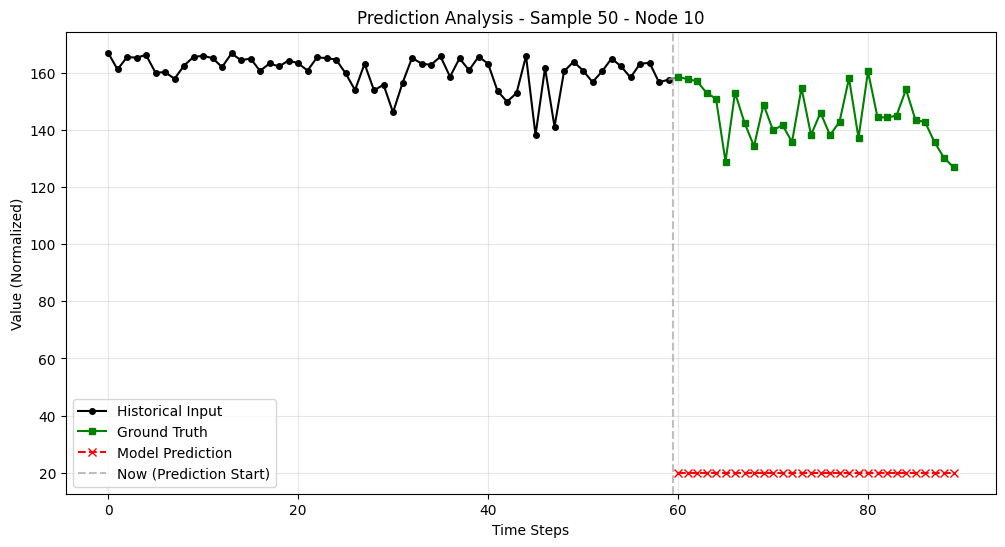

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def plot_prediction_window(model, dataset, sample_idx, node_idx, scaler=None):
    """
    Plots the history + future for a single specific window sample.
    
    Args:
        model: The trained PyTorch model.
        dataset: The TensorDataset containing (X, TE_his, TE_pred, Y).
        sample_idx: Integer, which specific window to plot (0 to len(dataset)).
        node_idx: Integer, which sensor/node to look at.
        scaler: (Optional) The sklearn Standard/MinMax Scaler used for normalization
                to inverse transform values back to real units (e.g., speed).
    """
    model.eval()
    device = next(model.parameters()).device
    
    # 1. Retrieve Data
    # Dataset returns tuple (X, TE_his, TE_pred, Y)
    X, TE_his, TE_pred, Y_true = dataset[sample_idx]
    
    # 2. Add Batch Dimension (1, T, N, C) for the model
    X_in = X.unsqueeze(0).to(device)
    TE_his_in = TE_his.unsqueeze(0).to(device)
    TE_pred_in = TE_pred.unsqueeze(0).to(device)
    
    # 3. Predict
    with torch.no_grad():
        Y_pred = model(X_in, TE_his_in, TE_pred_in)
        
    # 4. Extract Series for the specific Node
    # Shape is (1, Steps, Nodes, 1) -> Flatten to (Steps,)
    hist_data = X_in[0, :, node_idx, 0].cpu().numpy()
    true_data = Y_true[:, node_idx, 0].cpu().numpy()
    pred_data = Y_pred[0, :, node_idx, 0].cpu().numpy()
    
    # 5. Inverse Transform (if scaler provided)
    if scaler:
        # Note: Scalers usually expect (Samples, Features). 
        # We cheat slightly by repeating the shape if the scaler was fitted on the whole matrix
        # Or simplistic un-scaling: value * std + mean
        pass 
        # Implementation depends on how you scaled. 
        # If you scaled the whole dataframe:
        # hist_data = scaler.inverse_transform(hist_data.reshape(-1, 1))
    
    # 6. Setup Timeline
    hist_steps = len(hist_data)
    pred_steps = len(pred_data)
    total_steps = hist_steps + pred_steps
    
    time_hist = range(0, hist_steps)
    time_future = range(hist_steps, total_steps)
    
    # 7. Plotting
    plt.figure(figsize=(12, 6))
    
    # Plot History (Black)
    plt.plot(time_hist, hist_data, label='Historical Input', color='black', marker='o', markersize=4)
    
    # Connect history to future (Visual continuity)
    plt.plot([hist_steps-1, hist_steps], [hist_data[-1], true_data[0]], color='gray', linestyle='--')
    
    # Plot Ground Truth (Green)
    plt.plot(time_future, true_data, label='Ground Truth', color='green', marker='s', markersize=4)
    
    # Plot Prediction (Red)
    plt.plot(time_future, pred_data, label='Model Prediction', color='red', linestyle='--', marker='x', markersize=6)
    
    # Aesthetics
    plt.axvline(x=hist_steps-0.5, color='gray', linestyle='--', alpha=0.5, label='Now (Prediction Start)')
    plt.title(f"Prediction Analysis - Sample {sample_idx} - Node {node_idx}")
    plt.xlabel("Time Steps")
    plt.ylabel("Value (Normalized)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Usage:
plot_prediction_window(MODEL, DATA_DS, sample_idx=50, node_idx=10)

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx

def build_link_graph(router_edges):
    """
    Transforms a physical router map into a Link-Graph for GMAN.
    
    Args:
        router_edges: List of tuples (Router_Source, Router_Target, Link_ID)
                      Example: [('R1', 'R2', 'Link_1'), ('R2', 'R3', 'Link_2')]
    
    Returns:
        link_adj: Adjacency matrix (Num_Links x Num_Links)
        link_id_map: List showing which matrix index corresponds to which Link_ID
    """
    # 1. Create the Line Graph using NetworkX
    # We use a directed graph because Traffic A->B is different from B->A
    G_physical = nx.DiGraph()
    
    # Add physical edges. We store 'Link_ID' as an attribute to track it
    for src, dst, link_id in router_edges:
        G_physical.add_edge(src, dst, id=link_id)
        
    # 2. Convert to Line Graph
    # In a Line Graph, nodes are the edges of the original graph.
    # Two nodes are connected if the original edges shared a vertex.
    G_line = nx.line_graph(G_physical)
    
    # 3. Extract Mappings
    # G_line nodes are tuples like ('R1', 'R2'). We need to map these back to 'Link_1'
    sorted_nodes = sorted(list(G_line.nodes())) # Fix the order for the matrix
    
    link_id_list = []
    for u, v in sorted_nodes:
        # Retrieve the original Link ID we stored
        link_id = G_physical[u][v]['id']
        link_id_list.append(link_id)
        
    # 4. Build Adjacency Matrix
    # We use the sorted_nodes order to ensure matrix aligns with link_id_list
    link_adj = nx.to_numpy_array(G_line, nodelist=sorted_nodes)
    
    return link_adj, link_id_list

# ==========================================
# Example Usage
# ==========================================

# 1. Define Physical Connections (Router -> Router)
# Tuple: (Source Router, Target Router, Name of the Link)
physical_topology = [
    ('Router_A', 'Router_B', 'Link_AB'), # Traffic going A to B
    ('Router_B', 'Router_A', 'Link_BA'), # Traffic going B to A (Different Link/Interface!)
    ('Router_B', 'Router_C', 'Link_BC'),
    ('Router_C', 'Router_B', 'Link_CB'),
    ('Router_B', 'Router_D', 'Link_BD')
]


physical_topology = [(x[0],x[1],f"{x[0]}_{x[1]}") for x in DATA_RAW.index.values]

# 2. Build the GMAN inputs
adj_matrix, master_link_list = build_link_graph(physical_topology)

print("--- GMAN Nodes (Physical Links) ---")
print(master_link_list) 
# Output example: ['Link_AB', 'Link_BA', 'Link_BC', 'Link_BD', 'Link_CB']

print("\n--- GMAN Adjacency Matrix Shape ---")
print(adj_matrix.shape) 
# Output: (5, 5). Because we have 5 directional links.

# 3. Integrate with Data
# Suppose your CSV columns are: ['timestamp', 'Link_AB', 'Link_BC', ...]
# You must reorder your DataFrame columns to match 'master_link_list' exactly!

--- GMAN Nodes (Physical Links) ---
['910c_afs_camar_oriente_r6_csr_02605_02_605', '910c_afs_camar_oriente_r6_csr_02605_910c_rio_lauca_csr_r6_02045', '910c_aguas_anf_balm_csr_r5_02413_02_413', '910c_aguas_anf_ctro_csr_r2_02408_02_408', '910c_aguas_anf_ctro_csr_r2_02408_910c_av_arg_toyota_csr_r2_02323', '910c_aguas_anf_prat_csr_r5_02404_02_404', '910c_aguas_anf_prat_csr_r5_02404_910c_aguas_anf_balm_csr_r5_02413', '910c_aguas_el_salto_csr_r8_02411_02_411', '910c_aguas_el_salto_csr_r8_02411_910c_anf_el_ancla_csr_r8_02407', '910c_anf_cementerio_csr_r8_02421_02_421', '910c_anf_el_ancla_csr_r8_02407_02_407', '910c_anf_el_ancla_csr_r8_02407_910c_anf_cementerio_csr_r8_02421', '910c_ant_salida_sur_csr_r3_02361_02_361', '910c_antf_aguas_calientes_csr_02141_02_141', '910c_antf_aguas_calientes_csr_02141_910c_industrial_antf_csr_02075', '910c_antf_sierranev_csr_02541_02_541', '910c_anto_corvalis_csr_r5_02052_02_052', '910c_anto_corvalis_csr_r5_02052_910c_aguas_anf_prat_csr_r5_02404', '910c_antof_ho

In [ ]:
adj_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
G_raw = nx.DiGraph()
G_raw.add_edges_from(DATA_RAW.index.values)
G_raw = nx.line_graph(G_raw)


G_model = nx.Graph()
G_model.add_edges_from( [(EDGES_ID_DICT[x[0]], EDGES_ID_DICT[x[1]]) for x in G_raw.edges()] )
#G_model = G_model.to_undirected()

ADJ_M = nx.to_pandas_adjacency(G_model, dtype=int)
ADJ_M = ADJ_M.loc[DATA_RAW_MODEL.columns, DATA_RAW_MODEL.columns]
ADJ_M = ADJ_M.values
ADJ_M

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
ADJ_M.sum()

302